In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('CustomerChurnDataset/processed.csv')

In [3]:
df.info()
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                64374 non-null  int64  
 1   Gender             64374 non-null  int64  
 2   Tenure             64374 non-null  int64  
 3   Usage Frequency    64374 non-null  int64  
 4   Support Calls      64374 non-null  int64  
 5   Payment Delay      64374 non-null  int64  
 6   Subscription Type  64374 non-null  int64  
 7   Contract Length    64374 non-null  int64  
 8   Total Spend        64374 non-null  int64  
 9   Last Interaction   64374 non-null  int64  
 10  Churn              64374 non-null  int64  
 11  MonthlyCharges     64374 non-null  float64
dtypes: float64(1), int64(11)
memory usage: 5.9 MB


Churn
0    33881
1    30493
Name: count, dtype: int64

In [4]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64

In [5]:
# df = df.drop(columns=['Unnamed: 0'])

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

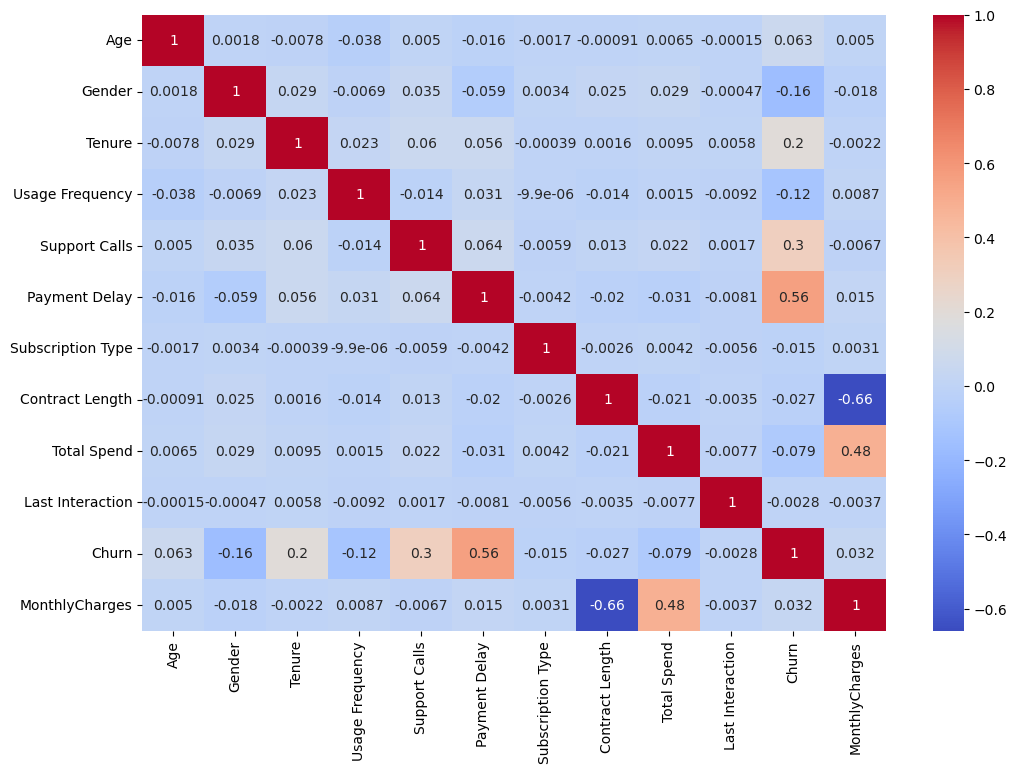

In [7]:
plt.figure(figsize = (12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

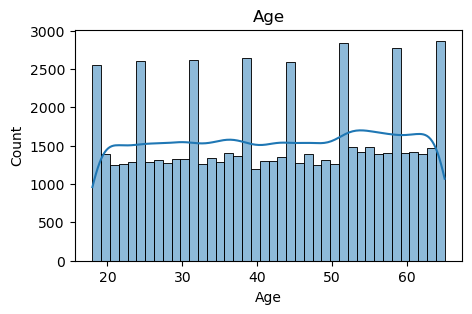

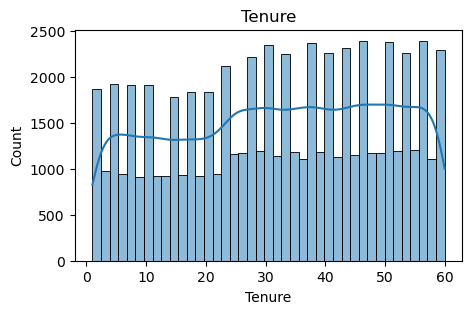

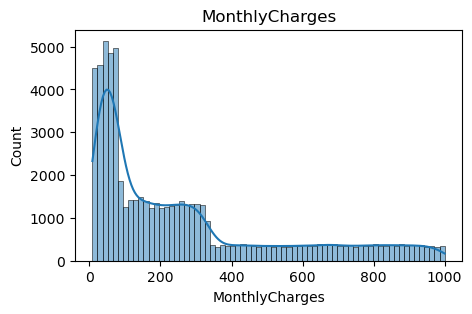

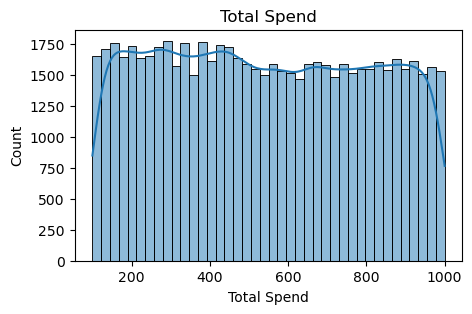

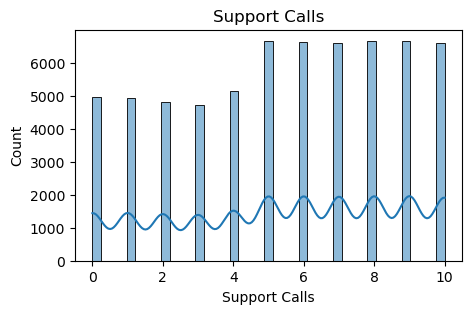

In [8]:
num_cols = ['Age','Tenure','MonthlyCharges','Total Spend','Support Calls']

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

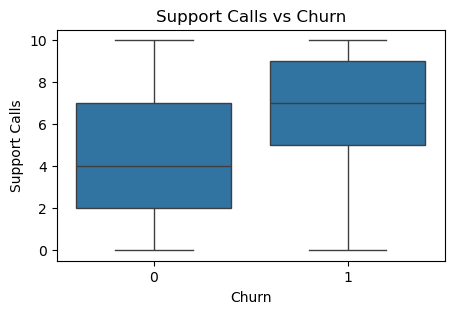

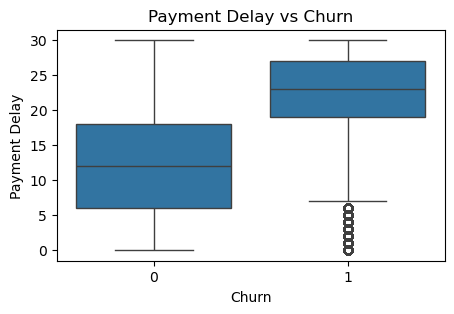

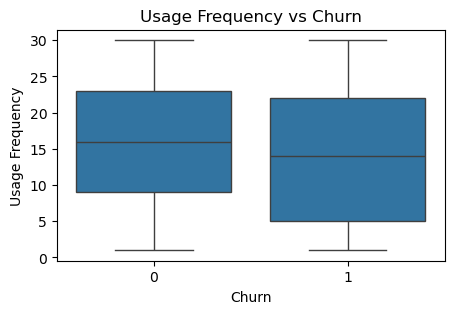

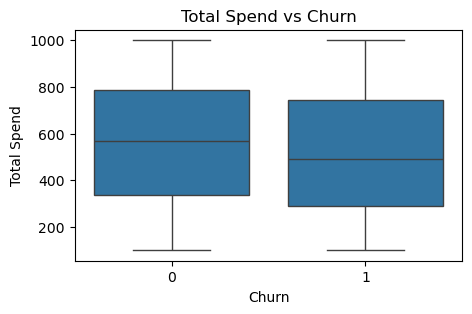

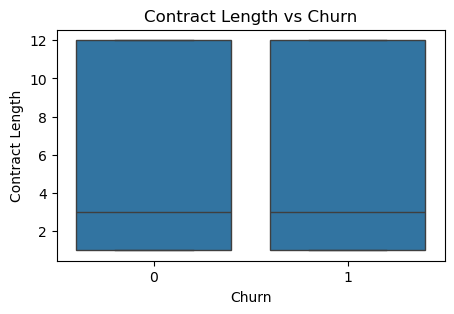

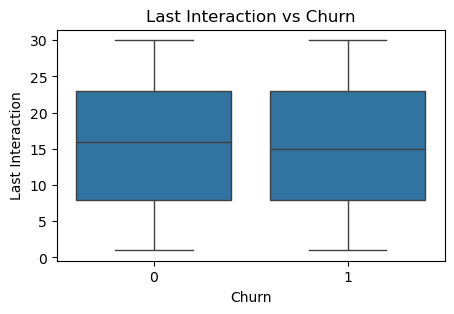

In [9]:
features = ['Support Calls','Payment Delay','Usage Frequency',
            'Total Spend','Contract Length','Last Interaction']

for col in features:
    plt.figure(figsize=(5,3))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.show()

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,64374.0,41.970982,13.924911,18.00,30.0,42.0,54.0,65.0
Gender,64374.0,0.466353,0.498870,0.00,0.0,0.0,1.0,1.0
Tenure,64374.0,31.994827,17.098234,1.00,18.0,33.0,47.0,60.0
Usage Frequency,64374.0,15.080234,8.816470,1.00,7.0,15.0,23.0,30.0
Support Calls,64374.0,5.400690,3.114005,0.00,3.0,6.0,8.0,10.0
Payment Delay,64374.0,17.133952,8.852211,0.00,10.0,19.0,25.0,30.0
Subscription Type,64374.0,1.999534,0.816084,1.00,1.0,2.0,3.0,3.0
Contract Length,64374.0,5.305745,4.795685,1.00,1.0,3.0,12.0,12.0
Total Spend,64374.0,541.023379,260.874809,100.00,313.0,534.0,768.0,1000.0
Last Interaction,64374.0,15.498850,8.638436,1.00,8.0,15.0,23.0,30.0


In [11]:
df.corr()['Churn'].sort_values(ascending=False)

Churn                1.000000
Payment Delay        0.557386
Support Calls        0.304631
Tenure               0.195327
Age                  0.063457
MonthlyCharges       0.032399
Last Interaction    -0.002818
Subscription Type   -0.014555
Contract Length     -0.026573
Total Spend         -0.078867
Usage Frequency     -0.115098
Gender              -0.164549
Name: Churn, dtype: float64

In [12]:
df['RiskScore'] = df['Payment Delay'] + df['Support Calls']

In [13]:
df['Engagement'] = df['Usage Frequency'] / (df['Tenure'] + 1)

In [14]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,MonthlyCharges,RiskScore,Engagement
0,22,0,25,14,4,27,1,1,598,9,1,598.00,31,0.538462
1,41,0,28,28,7,13,2,1,584,20,0,584.00,20,0.965517
2,47,1,27,10,2,29,3,12,757,21,0,63.08,31,0.357143
3,35,1,9,12,5,17,3,3,232,18,0,77.33,22,1.200000
4,53,0,58,24,9,2,2,12,533,18,0,44.42,11,0.406780


In [15]:
df.to_csv('CustomerChurnDataset\Eda_processed.csv')